# Exploratory Data Analysis & Feature Engineering

## Objective

This notebook explores the relationships between customer characteristics and churn in order to identify meaningful business patterns and develop candidate features for predictive modeling.

The analysis will focus on:

- Customer tenure
- Revenue and billing behavior
- Service usage
- Customer care activity
- Retention interactions
- Equipment characteristics
- Demographic characteristics
- Churn-related behavioral patterns

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.s3 import load_csv_from_s3

In [3]:
df = load_csv_from_s3("raw/cell2celltrain.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 51,047
Columns: 58


## 1. Customer Tenure and Churn

Analyze whether customer tenure differs between customers who churn and customers who remain with the company.

In [4]:
tenure_by_churn = (
    df.groupby("Churn")["MonthsInService"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

tenure_by_churn

,count,mean,median,std
Churn,,,,
No,36336,18.64,16.0,9.98
Yes,14711,19.04,17.0,9.34


### Tenure Groups

Group customers by months in service to examine whether churn rates vary across different stages of the customer lifecycle.

In [6]:
tenure_bins = [0, 12, 24, 36, 48, float("inf")]
tenure_labels = [
    "6-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49+ months"
]

df["TenureGroup"] = pd.cut(
    df["MonthsInService"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
6-12 months,73.37,26.63
13-24 months,69.23,30.77
25-36 months,71.20,28.80
37-48 months,72.40,27.60
49+ months,73.76,26.24


### Tenure Group Churn Rate

Visualize churn rates across customer tenure groups to identify potential lifecycle periods associated with elevated churn.

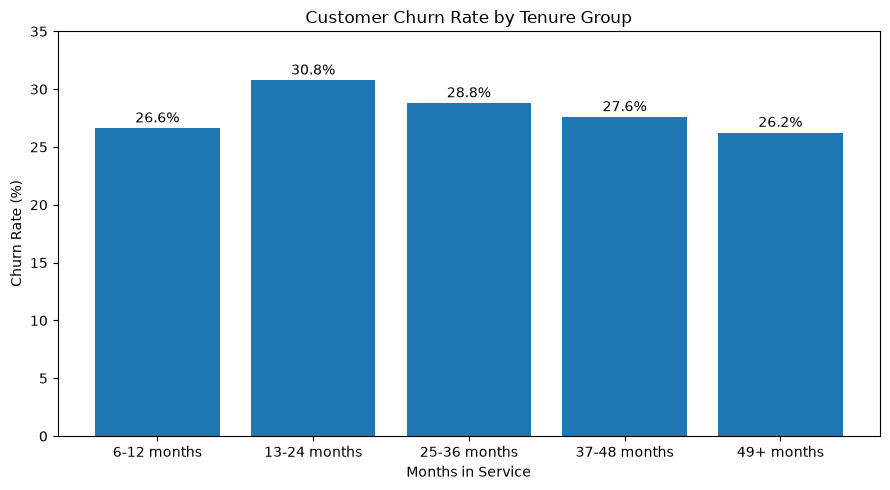

In [7]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_churn_rate.index.astype(str),
    tenure_churn_rate.values
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Months in Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)

for bar, rate in zip(bars, tenure_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 2. Revenue and Churn

Analyze whether monthly customer revenue differs between customers who churn and customers who remain with the company.

In [8]:
revenue_by_churn = (
    df.groupby("Churn")["MonthlyRevenue"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

revenue_by_churn

,count,mean,median,std
Churn,,,,
No,36250,59.17,48.82,44.50
Yes,14641,58.00,47.52,44.51


### Monthly Revenue Groups

Divide customers into revenue quartiles to examine whether churn rates vary across different levels of customer value.

In [9]:
df["RevenueGroup"] = pd.qcut(
    df["MonthlyRevenue"],
    q=4,
    labels=[
        "Low Revenue",
        "Lower-Middle Revenue",
        "Upper-Middle Revenue",
        "High Revenue"
    ]
)

revenue_group_summary = (
    df.groupby("RevenueGroup", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MinRevenue=("MonthlyRevenue", "min"),
        MaxRevenue=("MonthlyRevenue", "max"),
        MedianRevenue=("MonthlyRevenue", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

revenue_group_summary

,Customers,MinRevenue,MaxRevenue,MedianRevenue,ChurnRate
RevenueGroup,,,,,
Low Revenue,12728,-6.17,33.61,29.99,31.39
Lower-Middle Revenue,12721,33.62,48.46,38.99,27.13
Upper-Middle Revenue,12719,48.47,71.06,56.30,28.64
High Revenue,12723,71.07,1223.38,95.11,27.92


### Revenue Group Churn Rate

Visualize churn rates across monthly revenue quartiles to identify whether lower- or higher-value customers exhibit different churn behavior.

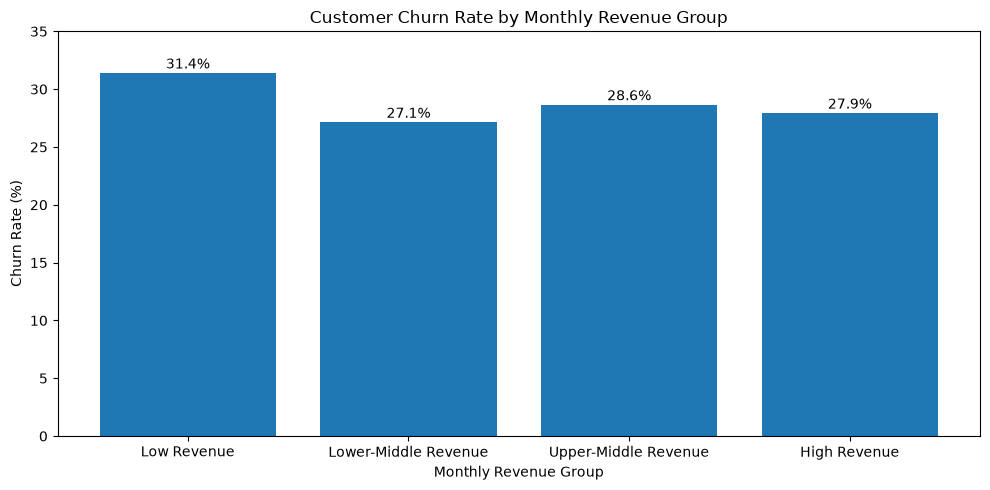

In [10]:
revenue_churn_rate = (
    df.groupby("RevenueGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    revenue_churn_rate.index.astype(str),
    revenue_churn_rate.values
)

plt.title("Customer Churn Rate by Monthly Revenue Group")
plt.xlabel("Monthly Revenue Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)

for bar, rate in zip(bars, revenue_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 3. Customer Usage Behavior and Churn

Compare customer usage and service-interaction metrics between churned and retained customers to identify behavioral differences associated with churn.

In [11]:
usage_columns = [
    "MonthlyMinutes",
    "OverageMinutes",
    "RoamingCalls",
    "DroppedCalls",
    "BlockedCalls",
    "UnansweredCalls",
    "CustomerCareCalls"
]

usage_by_churn = (
    df.groupby("Churn")[usage_columns]
    .mean()
    .T
    .round(2)
)

usage_by_churn["Difference"] = (
    usage_by_churn["Yes"] - usage_by_churn["No"]
).round(2)

usage_by_churn

Churn,No,Yes,Difference
MonthlyMinutes,542.55,483.83,-58.72
OverageMinutes,39.02,42.53,3.51
RoamingCalls,1.17,1.40,0.23
DroppedCalls,6.10,5.79,-0.31
BlockedCalls,4.12,3.99,-0.13
UnansweredCalls,29.01,26.50,-2.51
CustomerCareCalls,1.98,1.58,-0.40


### Monthly Usage Groups

Divide customers into monthly-minute quartiles to examine whether churn rates vary across different levels of service usage.

In [12]:
df["UsageGroup"] = pd.qcut(
    df["MonthlyMinutes"],
    q=4,
    labels=[
        "Low Usage",
        "Lower-Middle Usage",
        "Upper-Middle Usage",
        "High Usage"
    ]
)

usage_group_summary = (
    df.groupby("UsageGroup", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MinMinutes=("MonthlyMinutes", "min"),
        MaxMinutes=("MonthlyMinutes", "max"),
        MedianMinutes=("MonthlyMinutes", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

usage_group_summary

,Customers,MinMinutes,MaxMinutes,MedianMinutes,ChurnRate
UsageGroup,,,,,
Low Usage,12753,0.0,158.0,71.0,32.95
Lower-Middle Usage,12719,159.0,366.0,256.0,28.85
Upper-Middle Usage,12700,367.0,723.0,510.0,27.31
High Usage,12719,724.0,7359.0,1081.0,25.96


### Monthly Usage Group Churn Rate

Visualize churn rates across monthly usage quartiles to examine the relationship between customer engagement and churn.

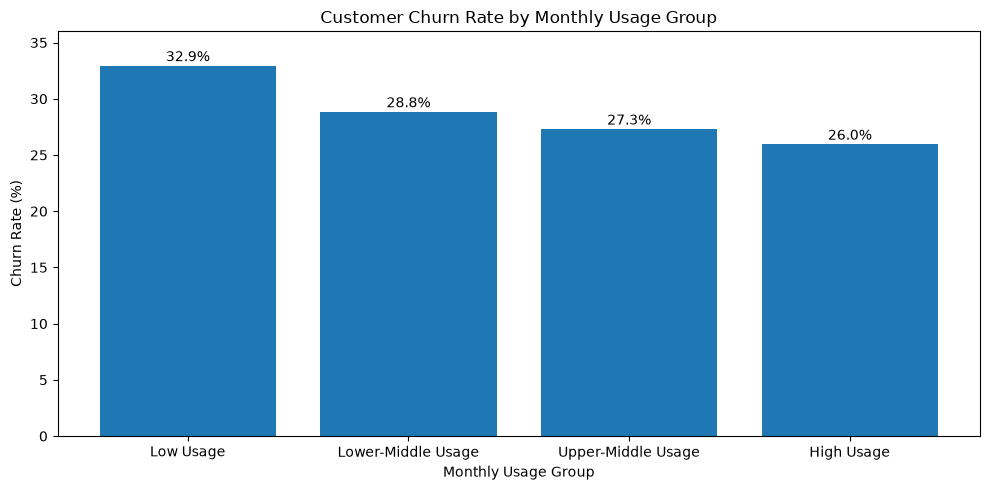

In [13]:
usage_churn_rate = (
    df.groupby("UsageGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    usage_churn_rate.index.astype(str),
    usage_churn_rate.values
)

plt.title("Customer Churn Rate by Monthly Usage Group")
plt.xlabel("Monthly Usage Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 36)

for bar, rate in zip(bars, usage_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Overage Usage and Churn

Examine whether customers who incur overage minutes have different churn behavior from customers with no overage usage.

In [14]:
df["HasOverage"] = np.where(
    df["OverageMinutes"] > 0,
    "Has Overage",
    "No Overage"
)

overage_summary = (
    df.groupby("HasOverage")
    .agg(
        Customers=("CustomerID", "count"),
        MeanOverageMinutes=("OverageMinutes", "mean"),
        MedianOverageMinutes=("OverageMinutes", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

overage_summary

,Customers,MeanOverageMinutes,MedianOverageMinutes,ChurnRate
HasOverage,,,,
Has Overage,27629,73.73,35.0,29.09
No Overage,23418,0.00,0.0,28.50


### Overage Intensity

Examine whether churn varies with the amount of overage usage rather than simply whether a customer has any overage minutes.

In [15]:
df["OverageGroup"] = "No Overage"

has_overage = df["OverageMinutes"] > 0

df.loc[has_overage, "OverageGroup"] = pd.qcut(
    df.loc[has_overage, "OverageMinutes"],
    q=3,
    labels=[
        "Low Overage",
        "Moderate Overage",
        "High Overage"
    ]
).astype(str)

overage_group_summary = (
    df.groupby("OverageGroup")
    .agg(
        Customers=("CustomerID", "count"),
        MinOverage=("OverageMinutes", "min"),
        MaxOverage=("OverageMinutes", "max"),
        MedianOverage=("OverageMinutes", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

overage_group_summary = overage_group_summary.reindex([
    "No Overage",
    "Low Overage",
    "Moderate Overage",
    "High Overage"
])

overage_group_summary

,Customers,MinOverage,MaxOverage,MedianOverage,ChurnRate
OverageGroup,,,,,
No Overage,23418,0.0,0.0,0.0,28.50
Low Overage,9607,1.0,18.0,7.0,27.00
Moderate Overage,8858,19.0,65.0,36.0,29.39
High Overage,9164,66.0,4321.0,126.0,31.00


### Overage Intensity Churn Rate

Visualize churn rates across overage-usage levels to determine whether heavier overage activity is associated with increased customer churn.

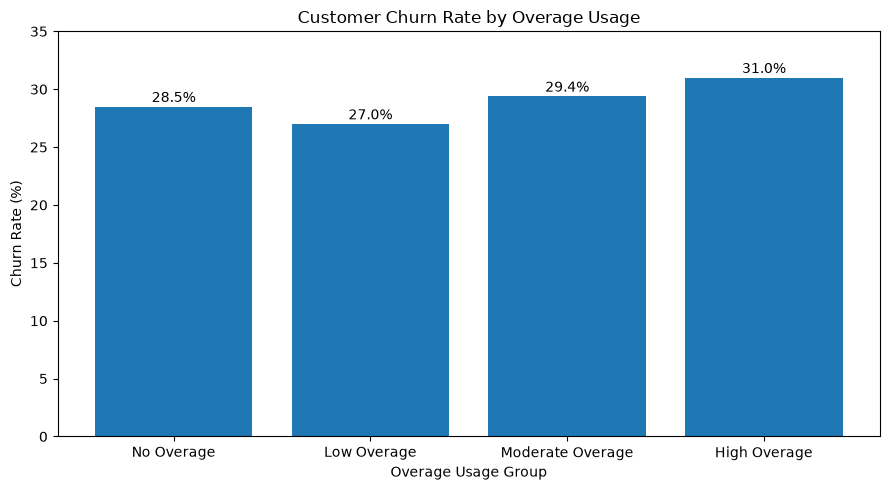

In [16]:
overage_churn_rate = overage_group_summary["ChurnRate"]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    overage_churn_rate.index,
    overage_churn_rate.values
)

plt.title("Customer Churn Rate by Overage Usage")
plt.xlabel("Overage Usage Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)

for bar, rate in zip(bars, overage_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 4. Customer Care, Retention, and Churn

Examine whether interactions with customer care and the retention team are associated with differences in customer churn.

In [17]:
retention_contact_summary = (
    df.groupby("MadeCallToRetentionTeam")
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

retention_contact_summary

,Customers,ChurnedCustomers,ChurnRate
MadeCallToRetentionTeam,,,
No,49302,13925,28.24
Yes,1745,786,45.04


### Retention Offers and Churn

Among customers with retention interactions, examine whether accepting a retention offer is associated with a different churn rate.

In [18]:
retention_customers = df[df["RetentionCalls"] > 0].copy()

retention_customers["AcceptedRetentionOffer"] = np.where(
    retention_customers["RetentionOffersAccepted"] > 0,
    "Accepted Offer",
    "No Accepted Offer"
)

retention_offer_summary = (
    retention_customers.groupby("AcceptedRetentionOffer")
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

retention_offer_summary

,Customers,ChurnedCustomers,ChurnRate
AcceptedRetentionOffer,,,
Accepted Offer,881,362,41.09
No Accepted Offer,864,424,49.07


### Customer Care Call Frequency

Examine churn rates across different levels of customer-care contact to determine whether the relationship between service interactions and churn is nonlinear.

In [19]:
df["CustomerCareGroup"] = pd.cut(
    df["CustomerCareCalls"],
    bins=[-1, 0, 2, 5, float("inf")],
    labels=[
        "No Calls",
        "1-2 Calls",
        "3-5 Calls",
        "6+ Calls"
    ]
)

customer_care_summary = (
    df.groupby("CustomerCareGroup", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MedianCareCalls=("CustomerCareCalls", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

customer_care_summary

,Customers,MedianCareCalls,ChurnRate
CustomerCareGroup,,,
No Calls,28020,0.0,30.72
1-2 Calls,12105,0.7,28.00
3-5 Calls,5422,3.3,25.01
6+ Calls,5500,9.0,24.65


### Customer Care Interaction Churn Rate

Visualize churn rates across levels of customer-care interaction to examine whether customer engagement with support is associated with churn behavior.

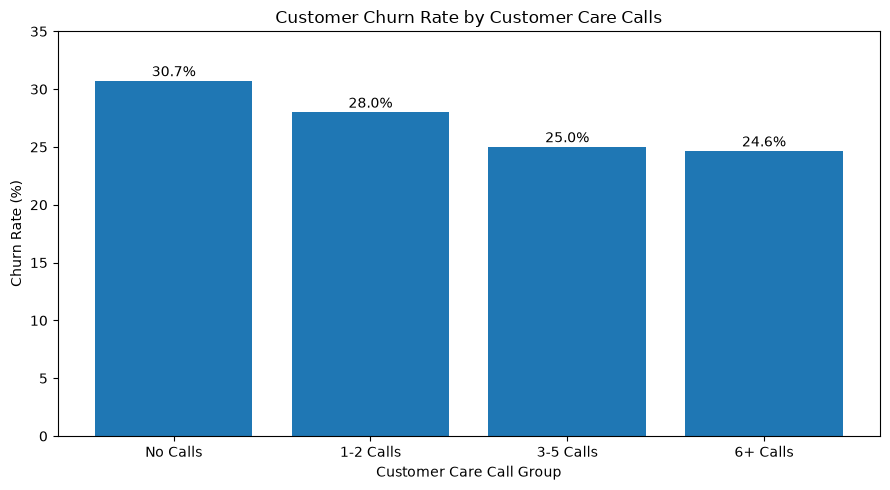

In [20]:
care_churn_rate = customer_care_summary["ChurnRate"]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    care_churn_rate.index.astype(str),
    care_churn_rate.values
)

plt.title("Customer Churn Rate by Customer Care Calls")
plt.xlabel("Customer Care Call Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)

for bar, rate in zip(bars, care_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 5. Equipment Characteristics and Churn

Analyze whether the age of a customer's current equipment is associated with churn. Negative equipment-day values identified during data profiling are excluded from this analysis.

In [21]:
valid_equipment = df[df["CurrentEquipmentDays"] >= 0].copy()

equipment_by_churn = (
    valid_equipment.groupby("Churn")["CurrentEquipmentDays"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

equipment_by_churn

,count,mean,median,std
Churn,,,,
No,36273,364.43,310.0,249.09
Yes,14697,422.31,366.0,259.73


### Equipment Age Groups

Divide customers into equipment-age quartiles to examine whether churn rates change as customers keep their current equipment for longer periods.

In [22]:
valid_equipment["EquipmentAgeGroup"] = pd.qcut(
    valid_equipment["CurrentEquipmentDays"],
    q=4,
    labels=[
        "Newest Equipment",
        "Newer Equipment",
        "Older Equipment",
        "Oldest Equipment"
    ]
)

equipment_group_summary = (
    valid_equipment.groupby("EquipmentAgeGroup", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MinDays=("CurrentEquipmentDays", "min"),
        MaxDays=("CurrentEquipmentDays", "max"),
        MedianDays=("CurrentEquipmentDays", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

equipment_group_summary

,Customers,MinDays,MaxDays,MedianDays,ChurnRate
EquipmentAgeGroup,,,,,
Newest Equipment,12751,0.0,205.0,112.0,22.03
Newer Equipment,12802,206.0,330.0,269.0,24.83
Older Equipment,12714,331.0,516.0,401.0,34.80
Oldest Equipment,12703,517.0,1812.0,685.0,33.73


### Equipment Age Churn Rate

Visualize churn rates across equipment-age groups to examine whether customers with older devices exhibit higher churn.

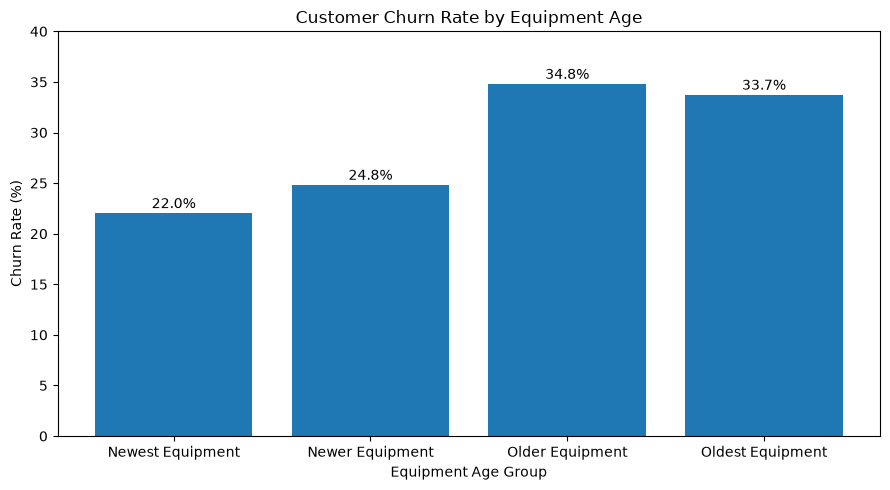

In [23]:
equipment_churn_rate = equipment_group_summary["ChurnRate"]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    equipment_churn_rate.index.astype(str),
    equipment_churn_rate.values
)

plt.title("Customer Churn Rate by Equipment Age")
plt.xlabel("Equipment Age Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 40)

for bar, rate in zip(bars, equipment_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Handset Characteristics

Examine whether refurbished and web-capable handsets are associated with different customer churn rates.

In [24]:
handset_characteristics = []

for column in ["HandsetRefurbished", "HandsetWebCapable"]:
    summary = (
        df.groupby(column)
        .agg(
            Customers=("CustomerID", "count"),
            ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
        )
        .round(2)
    )

    summary["Feature"] = column
    summary["Category"] = summary.index

    handset_characteristics.append(summary)

handset_summary = pd.concat(
    handset_characteristics,
    ignore_index=True
)

handset_summary = handset_summary[
    ["Feature", "Category", "Customers", "ChurnRate"]
]

handset_summary

,Feature,Category,Customers,ChurnRate
0,HandsetRefurbished,No,43956,28.27
1,HandsetRefurbished,Yes,7091,32.20
2,HandsetWebCapable,No,5001,37.35
3,HandsetWebCapable,Yes,46046,27.89


### Combined Handset Characteristics

Examine churn across combinations of handset refurbishment status and web capability to identify potentially higher-risk equipment profiles.

In [25]:
combined_handset_summary = (
    df.groupby(
        ["HandsetRefurbished", "HandsetWebCapable"]
    )
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=(
            "Churn",
            lambda x: (x == "Yes").sum()
        ),
        ChurnRate=(
            "Churn",
            lambda x: (x == "Yes").mean() * 100
        )
    )
    .round(2)
)

combined_handset_summary

Customers  ChurnedCustomers  ChurnRate
HandsetRefurbished HandsetWebCapable                                        
No                 No                      4068              1497      36.80
                   Yes                    39888             10931      27.40
Yes                No                       933               371      39.76
                   Yes                     6158              1912      31.05

### Handset Price and Churn

Examine whether handset price is associated with customer churn while preserving customers with unknown handset prices as a separate group.

In [26]:
df["HandsetPriceNumeric"] = pd.to_numeric(
    df["HandsetPrice"],
    errors="coerce"
)

df["HandsetPriceGroup"] = "Unknown"

known_price = df["HandsetPriceNumeric"].notna()

df.loc[known_price, "HandsetPriceGroup"] = pd.cut(
    df.loc[known_price, "HandsetPriceNumeric"],
    bins=[0, 50, 100, 200, float("inf")],
    labels=[
        "$50 or less",
        "$51-$100",
        "$101-$200",
        "Over $200"
    ],
    include_lowest=True
).astype(str)

handset_price_summary = (
    df.groupby("HandsetPriceGroup")
    .agg(
        Customers=("CustomerID", "count"),
        MedianPrice=("HandsetPriceNumeric", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

handset_price_summary = handset_price_summary.reindex([
    "Unknown",
    "$50 or less",
    "$51-$100",
    "$101-$200",
    "Over $200"
])

handset_price_summary

,Customers,MedianPrice,ChurnRate
HandsetPriceGroup,,,
Unknown,28982,NaN,30.17
$50 or less,9505,30.0,27.03
$51-$100,4971,80.0,27.40
$101-$200,7496,150.0,26.83
Over $200,93,400.0,25.81


## 6. Customer Demographics and Churn

Examine selected demographic and socioeconomic characteristics to determine whether customer segments exhibit different churn behavior.

In [27]:
demographic_columns = [
    "Homeownership",
    "CreditRating",
    "PrizmCode",
    "MaritalStatus"
]

for column in demographic_columns:
    summary = (
        df.groupby(column)
        .agg(
            Customers=("CustomerID", "count"),
            ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
        )
        .round(2)
        .sort_values("ChurnRate", ascending=False)
    )

    print(f"\n{column}")
    print(summary)


Homeownership
               Customers  ChurnRate
Homeownership                      
Unknown            17060      29.66
Known              33987      28.40

CreditRating
              Customers  ChurnRate
CreditRating                      
3-Good             8410      31.01
1-Highest          8522      30.84
2-High            18993      30.07
7-Lowest           2114      28.95
6-VeryLow          1152      27.43
4-Medium           5357      26.12
5-Low              6499      22.10

PrizmCode
           Customers  ChurnRate
PrizmCode                      
Rural           2425      31.71
Town            7589      29.99
Other          24655      28.62
Suburban       16378      28.14

MaritalStatus
               Customers  ChurnRate
MaritalStatus                      
Unknown            19700      30.19
Yes                18651      28.54
No                 12696      27.10


### Credit Rating and Churn

Examine churn rates across customer credit-rating categories to determine whether credit profile is associated with customer retention.

In [28]:
credit_order = [
    "1-Highest",
    "2-High",
    "3-Good",
    "4-Medium",
    "5-Low",
    "6-VeryLow",
    "7-Lowest"
]

credit_summary = (
    df.groupby("CreditRating")
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
    .reindex(credit_order)
)

credit_summary

,Customers,ChurnedCustomers,ChurnRate
CreditRating,,,
1-Highest,8522,2628,30.84
2-High,18993,5712,30.07
3-Good,8410,2608,31.01
4-Medium,5357,1399,26.12
5-Low,6499,1436,22.10
6-VeryLow,1152,316,27.43
7-Lowest,2114,612,28.95


### Credit Rating Churn Rate

Visualize churn rates across ordered credit-rating categories to identify nonlinear differences in churn behavior.

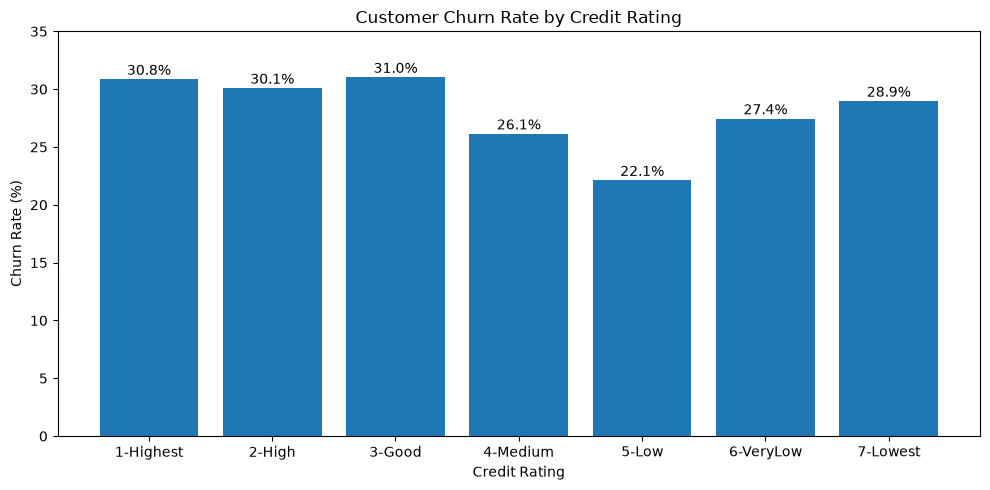

In [29]:
credit_churn_rate = credit_summary["ChurnRate"]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    credit_churn_rate.index,
    credit_churn_rate.values
)

plt.title("Customer Churn Rate by Credit Rating")
plt.xlabel("Credit Rating")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)

for bar, rate in zip(bars, credit_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Feature Engineering

Based on patterns identified during exploratory analysis, candidate features are created to represent customer engagement, equipment lifecycle, billing behavior, service interactions, and customer characteristics.

These features are initially evaluated in the notebook before being moved into a reusable feature-engineering pipeline.

In [30]:
df["MinutesPerRevenueDollar"] = np.where(
    df["MonthlyRevenue"] > 0,
    df["MonthlyMinutes"] / df["MonthlyRevenue"],
    np.nan
)

df["MinutesPerRevenueDollar"].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).round(2)

count    50882.00
mean         8.80
std          7.61
min          0.00
1%           0.00
5%           0.75
50%          7.29
95%         22.13
99%         35.79
max        237.49
Name: MinutesPerRevenueDollar, dtype: float64

### Usage-to-Revenue Engagement

Evaluate whether the amount of monthly service usage generated per dollar of monthly revenue is associated with customer churn.

In [31]:
engagement_by_churn = (
    df.groupby("Churn")["MinutesPerRevenueDollar"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

engagement_by_churn

,count,mean,median,std
Churn,,,,
No,36243,9.05,7.55,7.51
Yes,14639,8.17,6.69,7.80


### Equipment Age Relative to Customer Tenure

Create a feature comparing the age of a customer's current equipment with their total time in service to capture equipment lifecycle relative to customer tenure.

In [32]:
df["EquipmentAgeToTenure"] = np.where(
    (df["CurrentEquipmentDays"] >= 0)
    & (df["MonthsInService"] > 0),
    df["CurrentEquipmentDays"] / (df["MonthsInService"] * 30.44),
    np.nan
)

df["EquipmentAgeToTenure"].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).round(2)

count    50970.00
mean         0.73
std          0.34
min          0.00
1%           0.01
5%           0.08
50%          0.95
95%          1.02
99%          1.05
max          1.07
Name: EquipmentAgeToTenure, dtype: float64

In [33]:
equipment_ratio_by_churn = (
    df.groupby("Churn")["EquipmentAgeToTenure"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

equipment_ratio_by_churn

,count,mean,median,std
Churn,,,,
No,36273,0.714,0.943,0.351
Yes,14697,0.767,0.957,0.316


### Total Call Activity

Combine incoming, outgoing, and received call activity into a single feature representing overall customer calling engagement.

In [34]:
df["TotalCallActivity"] = (
    df["ReceivedCalls"]
    + df["OutboundCalls"]
    + df["InboundCalls"]
)

total_activity_by_churn = (
    df.groupby("Churn")["TotalCallActivity"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

total_activity_by_churn

,count,mean,median,std
Churn,,,,
No,36336,153.41,79.1,206.88
Yes,14711,135.87,65.1,192.24


### Dropped and Blocked Call Consistency

Verify whether the existing `DroppedBlockedCalls` variable represents the combined total of dropped and blocked calls before creating any redundant engineered feature.

In [35]:
calculated_dropped_blocked = (
    df["DroppedCalls"] + df["BlockedCalls"]
)

difference = (
    calculated_dropped_blocked
    - df["DroppedBlockedCalls"]
).abs()

print(
    "Exact matches:",
    (difference < 1e-9).sum()
)

print(
    "Non-matches:",
    (difference >= 1e-9).sum()
)

print(
    "Maximum difference:",
    difference.max()
)

Exact matches: 41055
Non-matches: 9992
Maximum difference: 103.69999999999999


### Dropped and Blocked Call Differences

Investigate records where the combined dropped and blocked call counts differ from the existing `DroppedBlockedCalls` feature.

In [36]:
comparison = df[
    [
        "DroppedCalls",
        "BlockedCalls",
        "DroppedBlockedCalls"
    ]
].copy()

comparison["CalculatedSum"] = (
    comparison["DroppedCalls"]
    + comparison["BlockedCalls"]
)

comparison["Difference"] = (
    comparison["CalculatedSum"]
    - comparison["DroppedBlockedCalls"]
)

comparison.loc[
    comparison["Difference"].abs() >= 1e-9
].head(15)

,DroppedCalls,BlockedCalls,DroppedBlockedCalls,CalculatedSum,Difference
0,0.7,0.7,1.3,1.4,0.1
34,0.3,24.3,24.7,24.6,-0.1
35,5.3,2.3,7.7,7.6,-0.1
43,0.3,2.3,2.7,2.6,-0.1
55,2.7,1.7,4.3,4.4,0.1
61,3.7,5.3,9.3,9.0,-0.3
65,0.7,0.7,1.3,1.4,0.1
70,4.3,1.3,5.7,5.6,-0.1
77,27.3,19.3,46.7,46.6,-0.1
78,1.3,18.3,19.7,19.6,-0.1


### Dropped and Blocked Call Difference Distribution

Quantify the magnitude of differences between the calculated sum of dropped and blocked calls and the existing `DroppedBlockedCalls` variable to distinguish minor rounding differences from substantial discrepancies.

In [38]:
difference_summary = difference.describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
).round(2)

difference_summary

for threshold in [0.1, 0.5, 1, 5, 10]:
    count = int((difference > threshold).sum())
    percent = count / len(df) * 100

    print(
        f"Difference > {threshold}: "
        f"{count:,} rows ({percent:.2f}%)"
    )

Difference > 0.1: 5,695 rows (11.16%)
Difference > 0.5: 1,006 rows (1.97%)
Difference > 1: 590 rows (1.16%)
Difference > 5: 104 rows (0.20%)
Difference > 10: 43 rows (0.08%)


### Customer Interaction Indicator

Create a binary feature indicating whether a customer has had any recorded interaction with customer care, retention, or director-assisted services.

In [39]:
df["HasServiceInteraction"] = (
    (df["CustomerCareCalls"] > 0)
    | (df["RetentionCalls"] > 0)
    | (df["DirectorAssistedCalls"] > 0)
).astype(int)

service_interaction_summary = (
    df.groupby("HasServiceInteraction")
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

service_interaction_summary

,Customers,ChurnedCustomers,ChurnRate
HasServiceInteraction,,,
0,15236,4701,30.85
1,35811,10010,27.95


### Low Usage Indicator

Create a binary feature identifying customers in the lowest quartile of monthly service usage, based on the elevated churn rate observed during exploratory analysis.

In [40]:
df["LowUsage"] = (
    df["MonthlyMinutes"] <= 158
).astype(int)

low_usage_summary = (
    df.groupby("LowUsage")
    .agg(
        Customers=("CustomerID", "count"),
        MedianMonthlyMinutes=("MonthlyMinutes", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

low_usage_summary

,Customers,MedianMonthlyMinutes,ChurnRate
LowUsage,,,
0,38294,510.0,27.44
1,12753,71.0,32.95


### Older Equipment Indicator

Create a binary feature identifying customers with older equipment based on the elevated churn rates observed among customers whose equipment age exceeds approximately 330 days.

In [41]:
df["OlderEquipment"] = np.where(
    df["CurrentEquipmentDays"].isna(),
    np.nan,
    np.where(
        df["CurrentEquipmentDays"] > 330,
        1,
        0
    )
)

older_equipment_summary = (
    df.groupby("OlderEquipment")
    .agg(
        Customers=("CustomerID", "count"),
        MedianEquipmentDays=("CurrentEquipmentDays", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

older_equipment_summary

,Customers,MedianEquipmentDays,ChurnRate
OlderEquipment,,,
0.0,25629,205.0,23.42
1.0,25417,516.0,34.26


### High Overage Indicator

Create a binary feature identifying customers with high overage usage based on the elevated churn rate observed among customers with more than 65 overage minutes.

In [42]:
df["HighOverage"] = np.where(
    df["OverageMinutes"].isna(),
    np.nan,
    np.where(
        df["OverageMinutes"] >= 66,
        1,
        0
    )
)

high_overage_summary = (
    df.groupby("HighOverage")
    .agg(
        Customers=("CustomerID", "count"),
        MedianOverageMinutes=("OverageMinutes", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

high_overage_summary

,Customers,MedianOverageMinutes,ChurnRate
HighOverage,,,
0.0,41727,0.0,28.28
1.0,9164,126.0,31.00


### Low Usage and Older Equipment Interaction

Create an interaction feature identifying customers who exhibit both low service usage and older equipment. These characteristics were individually associated with elevated churn during exploratory analysis.

In [43]:
df["LowUsageOlderEquipment"] = np.where(
    df["MonthlyMinutes"].isna()
    | df["CurrentEquipmentDays"].isna(),
    np.nan,
    (
        (df["MonthlyMinutes"] <= 158)
        & (df["CurrentEquipmentDays"] > 330)
    ).astype(int)
)

low_usage_old_equipment_summary = (
    df.groupby("LowUsageOlderEquipment")
    .agg(
        Customers=("CustomerID", "count"),
        MedianMonthlyMinutes=("MonthlyMinutes", "median"),
        MedianEquipmentDays=("CurrentEquipmentDays", "median"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

low_usage_old_equipment_summary

,Customers,MedianMonthlyMinutes,MedianEquipmentDays,ChurnRate
LowUsageOlderEquipment,,,,
0.0,42220,460.0,290.5,27.22
1.0,8670,66.0,597.0,36.30


### High-Risk Handset Profile

Create an interaction feature identifying customers with both a refurbished and non-web-capable handset, a combination associated with elevated churn during exploratory analysis.

In [44]:
df["HighRiskHandset"] = (
    (df["HandsetRefurbished"] == "Yes")
    & (df["HandsetWebCapable"] == "No")
).astype(int)

high_risk_handset_summary = (
    df.groupby("HighRiskHandset")
    .agg(
        Customers=("CustomerID", "count"),
        ChurnedCustomers=("Churn", lambda x: (x == "Yes").sum()),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .round(2)
)

high_risk_handset_summary

,Customers,ChurnedCustomers,ChurnRate
HighRiskHandset,,,
0,50114,14340,28.61
1,933,371,39.76


## Reusable Feature Engineering Pipeline

Apply the reusable feature-engineering module and verify that all expected features are created correctly.

In [45]:
import importlib
import src.features.build_features

importlib.reload(src.features.build_features)

from src.features.build_features import build_features

In [46]:
featured_df = build_features(df)

print(f"Original shape: {df.shape}")
print(f"Featured shape: {featured_df.shape}")

Original shape: (51047, 75)
Featured shape: (51047, 75)


In [47]:
raw_test_df = load_csv_from_s3("raw/cell2celltrain.csv")

print(f"Raw shape: {raw_test_df.shape}")

Raw shape: (51047, 58)


In [48]:
featured_test_df = build_features(raw_test_df)

print(f"Raw shape: {raw_test_df.shape}")
print(f"Featured shape: {featured_test_df.shape}")

Raw shape: (51047, 58)
Featured shape: (51047, 66)


### Feature Pipeline Validation

Verify that the reusable feature-engineering pipeline creates all expected features and inspect missing values introduced by feature construction.

In [49]:
engineered_features = [
    "MinutesPerRevenueDollar",
    "EquipmentAgeToTenure",
    "TotalCallActivity",
    "LowUsage",
    "OlderEquipment",
    "HighOverage",
    "LowUsageOlderEquipment",
    "HighRiskHandset",
]

missing_engineered_features = [
    column
    for column in engineered_features
    if column not in featured_test_df.columns
]

print(f"Missing engineered features: {missing_engineered_features}")
print(
    f"All engineered features present: "
    f"{len(missing_engineered_features) == 0}"
)

featured_test_df[
    engineered_features
].isna().sum()

Missing engineered features: []
All engineered features present: True


MinutesPerRevenueDollar    165
EquipmentAgeToTenure        77
TotalCallActivity            0
LowUsage                   156
OlderEquipment               1
HighOverage                156
LowUsageOlderEquipment     157
HighRiskHandset              0
dtype: int64

### Engineered Feature Sanity Checks

Confirm that binary engineered features contain only valid binary values while allowing missing values where source data is unavailable.

In [50]:
binary_features = [
    "LowUsage",
    "OlderEquipment",
    "HighOverage",
    "LowUsageOlderEquipment",
    "HighRiskHandset",
]

for column in binary_features:
    values = sorted(
        featured_test_df[column]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"{column}: {values}")

LowUsage: [0.0, 1.0]
OlderEquipment: [0.0, 1.0]
HighOverage: [0.0, 1.0]
LowUsageOlderEquipment: [0.0, 1.0]
HighRiskHandset: [0, 1]


# EDA and Feature Engineering Summary

## Key Churn Findings

Exploratory analysis identified several customer characteristics associated with differences in churn behavior:

- **Customer usage:** Customers in the lowest monthly-usage quartile had a 32.95% churn rate compared with 25.96% among customers in the highest usage quartile.
- **Equipment age:** Customers with equipment older than approximately 330 days had a 34.26% churn rate compared with 23.42% among customers with newer equipment.
- **Retention interactions:** Customers who contacted the retention team had a 45.04% churn rate compared with 28.24% among customers without retention-team contact.
- **Retention offers:** Among customers who interacted with retention, customers who accepted an offer had a 41.09% churn rate compared with 49.07% among those who did not accept an offer.
- **Customer care:** Customers with no customer-care calls had a 30.72% churn rate compared with 24.65% among customers with six or more calls.
- **Overage usage:** Customers with high overage usage had a 31.00% churn rate compared with 27.00% among customers with low overage usage.
- **Handset characteristics:** Customers with non-web-capable handsets had substantially higher churn, and customers with both refurbished and non-web-capable handsets had a 39.76% churn rate.
- **Revenue:** The lowest monthly-revenue quartile had the highest observed churn rate at 31.39%.
- **Tenure:** Churn peaked among customers with 13–24 months of service at 30.77%, indicating a nonlinear relationship between tenure and churn.
- **Credit rating:** Churn varied nonlinearly across credit-rating categories rather than consistently increasing or decreasing with the recorded rating.

These findings represent associations in the observed data and should not be interpreted as causal relationships.

## Engineered Features

A reusable feature-engineering pipeline was created in `src/features/build_features.py`.

The pipeline creates the following candidate features:

- `MinutesPerRevenueDollar`
- `EquipmentAgeToTenure`
- `TotalCallActivity`
- `LowUsage`
- `OlderEquipment`
- `HighOverage`
- `LowUsageOlderEquipment`
- `HighRiskHandset`

The raw dataset contains 58 columns, while the feature-engineered dataset contains 66 columns.

Missing values are intentionally preserved where required source variables are unavailable so that missing-data treatment can be handled explicitly within the modeling pipeline.

Threshold-based features identified during exploratory analysis will require careful treatment during model development to ensure that information from validation or test data is not used when determining feature thresholds.

## Next Steps

The next phase will focus on predictive modeling, including:

- Train/validation/test strategy
- Target encoding
- Missing-value preprocessing
- Categorical-variable encoding
- Feature scaling where appropriate
- Baseline model development
- Logistic regression
- Tree-based models
- XGBoost
- Class-imbalance evaluation
- Model comparison and selection
- Classification threshold analysis
- Feature importance and model interpretation